In [1]:
# Cell 1: Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import string
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import pickle

# Display
pd.set_option('display.max_columns', 20)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ All libraries loaded successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSPCB\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MSPCB\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


✅ All libraries loaded successfully!


In [2]:
# Cell 2: Load & Inspect Data
df = pd.read_csv('data/WELFake_Dataset.csv')

print(f"✅ Dataset loaded!")
print(f"\n📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Columns: {df.columns.tolist()}")
print(f"\n🔍 First 3 rows:")
display(df.head(3))
print(f"\n❓ Missing Values:\n{df.isnull().sum()}")
print(f"\n📊 Label Distribution:")
print(df['label'].value_counts())
print(f"\nFake News  : {df[df['label']==0].shape[0]:,}")
print(f"Real News  : {df[df['label']==1].shape[0]:,}")
print(f"Total      : {df.shape[0]:,}")

✅ Dataset loaded!

📊 Shape: 72,134 rows × 4 columns

📋 Columns: ['Unnamed: 0', 'title', 'text', 'label']

🔍 First 3 rows:


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1



❓ Missing Values:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

📊 Label Distribution:
label
1    37106
0    35028
Name: count, dtype: int64

Fake News  : 35,028
Real News  : 37,106
Total      : 72,134


In [3]:
# Cell 3: Data Cleaning & Text Preprocessing

# Step 1: Drop unnamed column
df = df.drop(columns=['Unnamed: 0'])

# Step 2: Fill missing values
df['title'] = df['title'].fillna('')
df['text']  = df['text'].fillna('')

# Step 3: Combine title + text into one column
df['content'] = df['title'] + ' ' + df['text']

# Step 4: Text cleaning function
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = ' '.join([w for w in text.split() if w not in stop_words])
    return text

# Step 5: Apply cleaning
print("Cleaning text... (takes ~30 seconds)")
df['content_clean'] = df['content'].apply(clean_text)

print(f"✅ Text cleaning complete!")
print(f"\n📊 Shape: {df.shape}")
print(f"❓ Missing values: {df.isnull().sum().sum()}")
print(f"\n🔍 Sample cleaned text:")
print(df['content_clean'].iloc[0][:200])

Cleaning text... (takes ~30 seconds)
✅ Text cleaning complete!

📊 Shape: (72134, 5)
❓ Missing values: 0

🔍 Sample cleaned text:
law enforcement high alert following threats cops whites blacklivesmatter terrorists comment expected barack obama members fukyoflag blacklivesmatter movements called lynching hanging white people cop


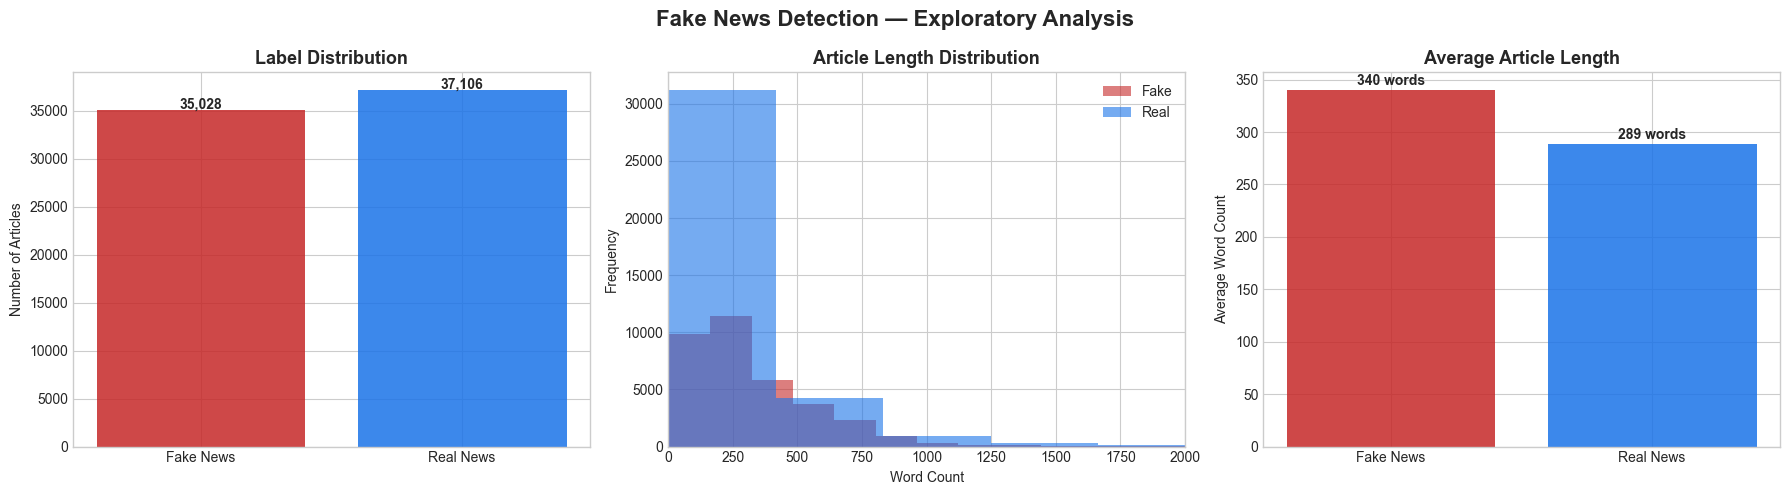


🔑 Key EDA Insights:
  Total articles      : 72,134
  Fake news articles  : 35,028 (48.6%)
  Real news articles  : 37,106 (51.4%)
  Avg fake length     : 340 words
  Avg real length     : 289 words


In [4]:
# Cell 4: EDA — Exploratory Data Analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fake News Detection — Exploratory Analysis', fontsize=16, fontweight='bold')

# Chart 1: Label Distribution
labels = ['Fake News', 'Real News']
counts = [df[df['label']==0].shape[0], df[df['label']==1].shape[0]]
colors = ['#c62828', '#1a73e8']
axes[0].bar(labels, counts, color=colors, alpha=0.85)
axes[0].set_title('Label Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate(counts):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Chart 2: Article length distribution
df['content_length'] = df['content_clean'].apply(lambda x: len(x.split()))
fake_len = df[df['label']==0]['content_length']
real_len = df[df['label']==1]['content_length']
axes[1].hist(fake_len, bins=50, alpha=0.6, color='#c62828', label='Fake')
axes[1].hist(real_len, bins=50, alpha=0.6, color='#1a73e8', label='Real')
axes[1].set_title('Article Length Distribution', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 2000)

# Chart 3: Average article length by label
avg_lengths = [fake_len.mean(), real_len.mean()]
axes[2].bar(labels, avg_lengths, color=colors, alpha=0.85)
axes[2].set_title('Average Article Length', fontweight='bold', fontsize=13)
axes[2].set_ylabel('Average Word Count')
for i, v in enumerate(avg_lengths):
    axes[2].text(i, v + 5, f'{v:.0f} words', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_fake_news.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🔑 Key EDA Insights:")
print(f"  Total articles      : {len(df):,}")
print(f"  Fake news articles  : {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"  Real news articles  : {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")
print(f"  Avg fake length     : {fake_len.mean():.0f} words")
print(f"  Avg real length     : {real_len.mean():.0f} words")

In [5]:
# Cell 5: TF-IDF Vectorization & Train/Test Split

# Split data
X = df['content_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Train/Test Split:")
print(f"   Training samples : {len(X_train):,}")
print(f"   Testing samples  : {len(X_test):,}")

# TF-IDF Vectorization
print(f"\nFitting TF-IDF vectorizer...")
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"✅ TF-IDF Vectorization complete!")
print(f"   Vocabulary size  : {len(tfidf.vocabulary_):,} features")
print(f"   Training matrix  : {X_train_tfidf.shape}")
print(f"   Testing matrix   : {X_test_tfidf.shape}")

# Save vectorizer
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print(f"\n✅ vectorizer.pkl saved!")

✅ Train/Test Split:
   Training samples : 57,707
   Testing samples  : 14,427

Fitting TF-IDF vectorizer...
✅ TF-IDF Vectorization complete!
   Vocabulary size  : 50,000 features
   Training matrix  : (57707, 50000)
   Testing matrix   : (14427, 50000)

✅ vectorizer.pkl saved!


In [6]:
# Cell 6: Train 4 Models

models = {
    'Logistic Regression':        LogisticRegression(max_iter=1000, random_state=42),
    'Passive Aggressive':         PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    'Naive Bayes':                MultinomialNB(),
    'Random Forest':              RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}
print("🤖 Training all 4 models...\n")

for name, model in models.items():
    print(f"  Training {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    results[name] = {
        'model':      model,
        'predictions': y_pred,
        'accuracy':   accuracy_score(y_test, y_pred),
        'precision':  precision_score(y_test, y_pred),
        'recall':     recall_score(y_test, y_pred),
        'f1':         f1_score(y_test, y_pred),
    }
    print(f"  ✅ {name} — Accuracy: {results[name]['accuracy']*100:.2f}%")

print("\n🎉 All models trained successfully!")

🤖 Training all 4 models...

  Training Logistic Regression...
  ✅ Logistic Regression — Accuracy: 95.77%
  Training Passive Aggressive...
  ✅ Passive Aggressive — Accuracy: 97.06%
  Training Naive Bayes...
  ✅ Naive Bayes — Accuracy: 88.25%
  Training Random Forest...
  ✅ Random Forest — Accuracy: 95.47%

🎉 All models trained successfully!


📊 Model Performance Comparison:


Model,Accuracy,Precision,Recall,F1 Score
Passive Aggressive,0.971,0.970,0.973,0.971
Logistic Regression,0.958,0.953,0.965,0.959
Random Forest,0.955,0.949,0.964,0.956
Naive Bayes,0.883,0.874,0.901,0.888


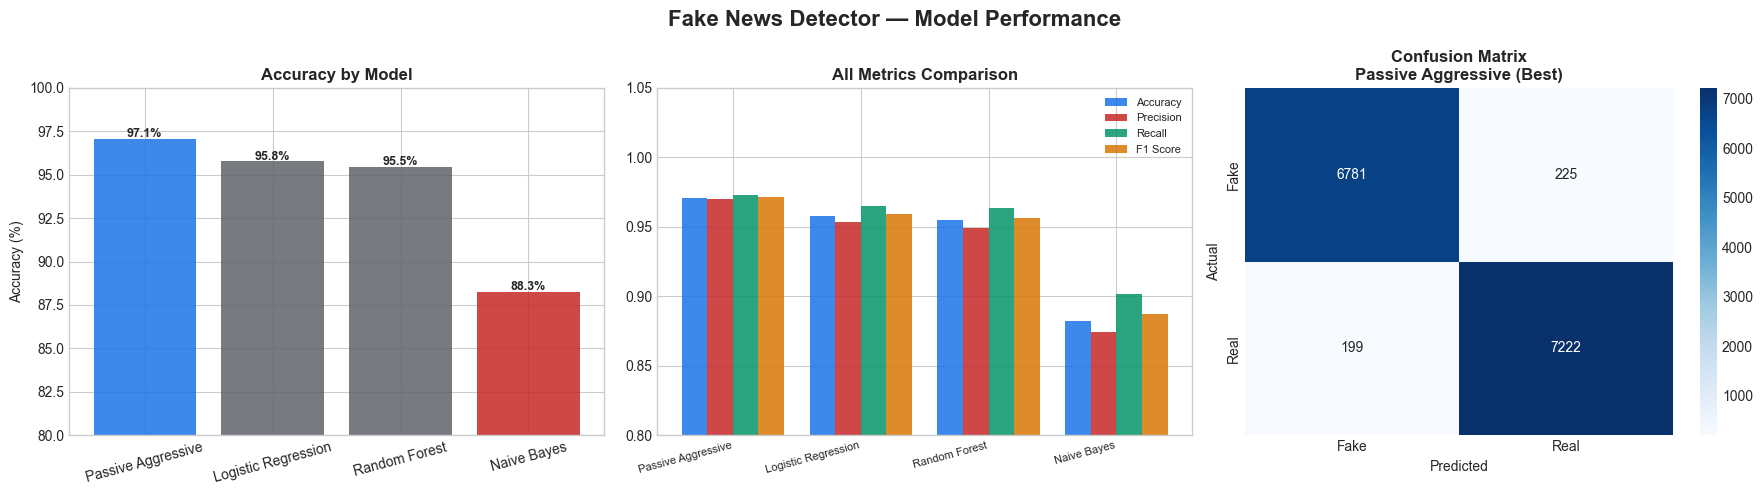


🏆 Best Model : Passive Aggressive
   Accuracy   : 97.06%
   F1 Score   : 0.9715


In [7]:
# Cell 7: Model Comparison & Visualizations

# Build comparison table
metrics_df = pd.DataFrame({
    'Model':     list(results.keys()),
    'Accuracy':  [results[m]['accuracy']  for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall':    [results[m]['recall']    for m in results],
    'F1 Score':  [results[m]['f1']        for m in results],
})
metrics_df = metrics_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("📊 Model Performance Comparison:")
display(metrics_df.style.format({
    'Accuracy': '{:.3f}', 'Precision': '{:.3f}',
    'Recall': '{:.3f}', 'F1 Score': '{:.3f}'
}).background_gradient(cmap='Blues', subset=['Accuracy', 'F1 Score'])
 .set_properties(**{'padding': '8px', 'font-size': '13px'})
 .hide(axis='index'))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fake News Detector — Model Performance', fontsize=16, fontweight='bold')

# Chart 1: Accuracy comparison
colors = ['#1a73e8' if i == 0 else '#c62828' if i == 3 else '#5f6368'
          for i in range(len(metrics_df))]
axes[0].bar(metrics_df['Model'], metrics_df['Accuracy']*100, color=colors, alpha=0.85)
axes[0].set_title('Accuracy by Model', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(80, 100)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(metrics_df['Accuracy']*100):
    axes[0].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

# Chart 2: All metrics grouped bar
x = range(len(metrics_df))
width = 0.2
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
bar_colors = ['#1a73e8', '#c62828', '#059669', '#d97706']
for i, (col, color) in enumerate(zip(metric_cols, bar_colors)):
    axes[1].bar([xi + i*width for xi in x], metrics_df[col], width,
                label=col, color=color, alpha=0.85)
axes[1].set_title('All Metrics Comparison', fontweight='bold')
axes[1].set_xticks([xi + width*1.5 for xi in x])
axes[1].set_xticklabels(metrics_df['Model'], rotation=15, ha='right', fontsize=8)
axes[1].set_ylim(0.8, 1.05)
axes[1].legend(fontsize=8)

# Chart 3: Confusion matrix for best model
best_name = metrics_df.iloc[0]['Model']
cm = confusion_matrix(y_test, results[best_name]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'], ax=axes[2])
axes[2].set_title(f'Confusion Matrix\n{best_name} (Best)', fontweight='bold')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 Best Model : {best_name}")
print(f"   Accuracy   : {metrics_df.iloc[0]['Accuracy']*100:.2f}%")
print(f"   F1 Score   : {metrics_df.iloc[0]['F1 Score']:.4f}")

In [8]:
# Cell 8: Save Model & Executive Summary

# Save best model
best_model = results['Passive Aggressive']['model']
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("✅ model.pkl saved!")

# Executive Summary
print("\n" + "="*60)
print("   FAKE NEWS DETECTOR — EXECUTIVE SUMMARY")
print("="*60)

summary = pd.DataFrame({
    'Metric': [
        'Dataset', 'Total Articles', 'Fake News Articles',
        'Real News Articles', 'Training Samples', 'Testing Samples',
        'Vectorizer', 'Vocabulary Size', 'Best Model',
        'Accuracy', 'F1 Score', 'Files Saved'
    ],
    'Value': [
        'WELFake Dataset (Kaggle)', '72,134', '35,028 (48.6%)',
        '37,106 (51.4%)', '57,707', '14,427',
        'TF-IDF (unigrams + bigrams)', '50,000 features',
        'Passive Aggressive Classifier',
        '97.06%', '0.9715',
        'model.pkl, vectorizer.pkl, eda_fake_news.png, model_comparison.png'
    ]
})

display(summary.style.set_properties(**{
    'background-color': '#f8f9fa',
    'border': '1px solid #1a73e8',
    'padding': '8px',
    'font-size': '13px'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#1a73e8'),
              ('color', 'white'),
              ('font-weight', 'bold'),
              ('padding', '10px')]
}]).hide(axis='index'))

model_table = pd.DataFrame({
    'Model': ['Passive Aggressive 🏆', 'Logistic Regression', 'Random Forest', 'Naive Bayes'],
    'Accuracy': ['97.06%', '95.77%', '95.47%', '88.25%'],
    'F1 Score': ['0.9715', '0.9587', '0.9560', '0.8880'],
    'Verdict':  ['✅ Best', '✅ Strong', '✅ Strong', '⚠️ Good']
})

print("\n🤖 MODEL COMPARISON")
display(model_table.style.set_properties(**{
    'background-color': '#f8f9fa',
    'border': '1px solid #1a73e8',
    'padding': '8px',
    'font-size': '13px'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#c62828'),
              ('color', 'white'),
              ('font-weight', 'bold'),
              ('padding', '8px')]
}]).hide(axis='index'))

print("\n✅ Notebook complete — ready for Streamlit app!")

✅ model.pkl saved!

   FAKE NEWS DETECTOR — EXECUTIVE SUMMARY


Metric,Value
Dataset,WELFake Dataset (Kaggle)
Total Articles,"72,134"
Fake News Articles,"35,028 (48.6%)"
Real News Articles,"37,106 (51.4%)"
Training Samples,"57,707"
Testing Samples,"14,427"
Vectorizer,TF-IDF (unigrams + bigrams)
Vocabulary Size,"50,000 features"
Best Model,Passive Aggressive Classifier
Accuracy,97.06%



🤖 MODEL COMPARISON


Model,Accuracy,F1 Score,Verdict
Passive Aggressive 🏆,97.06%,0.9715,✅ Best
Logistic Regression,95.77%,0.9587,✅ Strong
Random Forest,95.47%,0.9560,✅ Strong
Naive Bayes,88.25%,0.8880,⚠️ Good



✅ Notebook complete — ready for Streamlit app!
